### Theory Questions

1. What is a Support Vector Machine (SVM)?

    SVM is a supervised learning algorithm used for classification and regression.
    It finds the optimal hyperplane that maximizes the margin between different classes.

2. What is the difference between Hard Margin and Soft Margin SVM?

    Hard Margin SVM assumes perfectly separable data with no misclassification.
    Soft Margin SVM allows some misclassification using a penalty parameter (C) to handle noisy data.



3. What is the mathematical intuition behind SVM?

    SVM aims to maximize the margin between classes while minimizing classification error.
    It solves a convex optimization problem to find the optimal separating hyperplane.



4. What is the role of Lagrange Multipliers in SVM?

    They convert the constrained optimization problem into a dual form.
    This enables efficient computation and allows the use of kernel functions.

5. What are Support Vectors in SVM?

    Support vectors are the data points closest to the decision boundary.
    They directly determine the position and orientation of the hyperplane.



6. What is a Support Vector Classifier (SVC)?

    SVC is the classification implementation of SVM.
    It finds the optimal hyperplane to separate classes in feature space.



7. What is a Support Vector Regressor (SVR)?

    SVR is the regression version of SVM.
    It fits a function within a specified error margin (epsilon) while maximizing margin.



8. What is the Kernel Trick in SVM?

    The kernel trick maps data into a higher-dimensional space without explicit transformation.
    It allows SVM to handle non-linearly separable data efficiently.

9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.

    Linear kernel works for linearly separable data.
    Polynomial handles curved boundaries with degree control, while RBF captures complex non-linear patterns using gamma.



10. What is the effect of the C parameter in SVM?

    C controls the trade-off between maximizing margin and minimizing classification error.
    High C reduces misclassification but risks overfitting; low C increases margin but allows more errors.



11. What is the role of the Gamma parameter in RBF Kernel SVM?

    Gamma controls the influence of individual training points.
    High gamma creates complex boundaries; low gamma produces smoother decision surfaces.



12. What is the Naïve Bayes classifier, and why is it called "Naïve"?

    Naïve Bayes is a probabilistic classifier based on Bayes’ Theorem.
    It is called “naïve” because it assumes independence among features.



13. What is Bayes’ Theorem?

    Bayes’ Theorem describes the probability of a hypothesis given observed evidence.
    It updates prior belief using likelihood and evidence.

14. Explain the differences between Gaussian, Multinomial, and Bernoulli Naïve Bayes.

    Gaussian NB is used for continuous features assuming normal distribution.
    Multinomial NB works with count data, while Bernoulli NB is suited for binary features.



15. When should you use Gaussian Naïve Bayes over other variants?

    Use Gaussian NB when features are continuous and approximately normally distributed.
    It is suitable for real-valued measurements.



16. What are the key assumptions made by Naïve Bayes?

    It assumes conditional independence among features given the class.
    It also assumes specific distribution forms depending on the variant.



17. What are the advantages and disadvantages of Naïve Bayes?

    Advantages include simplicity, fast training, and good performance on high-dimensional data.
    Disadvantages include strong independence assumption and limited performance on correlated features.



18. Why is Naïve Bayes a good choice for text classification?

    Text data is high-dimensional and sparse, which suits Naïve Bayes assumptions.
    It performs efficiently and requires relatively small training data.



19. Compare SVM and Naïve Bayes for classification tasks.

    SVM focuses on maximizing margin and handles complex boundaries well.
    Naïve Bayes is probabilistic, faster, and works well with high-dimensional sparse data.

20. How does Laplace Smoothing help in Naïve Bayes?

    Laplace smoothing prevents zero probabilities for unseen features.
    It adds a small constant to frequency counts to improve generalization.



In [1]:
# 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM
model = SVC()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [2]:
# 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies.
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear Kernel
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
linear_acc = accuracy_score(y_test, linear_svm.predict(X_test))

# RBF Kernel
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, rbf_svm.predict(X_test))

print("Linear Kernel Accuracy:", linear_acc)
print("RBF Kernel Accuracy:", rbf_acc)

Linear Kernel Accuracy: 0.9814814814814815
RBF Kernel Accuracy: 0.7592592592592593


In [3]:
# 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE).
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 1.3489971413208723


In [ ]:
# 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Create 2D dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

model = SVC(kernel='poly', degree=3)
model.fit(X, y)

# Plot decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Polynomial Kernel SVM Decision Boundary")
plt.show()

In [4]:
# 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9415204678362573


In [5]:
# 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Load dataset
data = fetch_20newsgroups(subset='all')
X, y = data.data, data.target

# Convert text to numerical features
vectorizer = CountVectorizer(stop_words='english')
X_vect = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.3, random_state=42)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8749557835160948


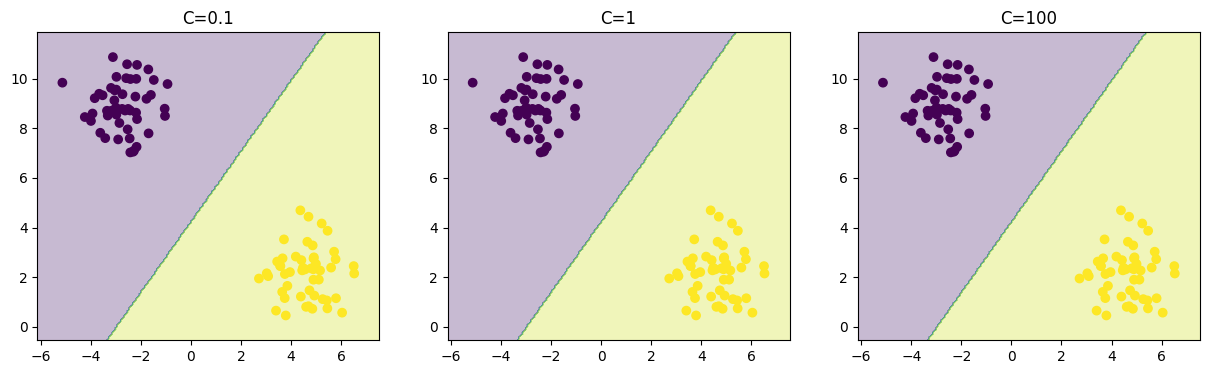

In [6]:
# 27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

X, y = make_blobs(n_samples=100, centers=2, random_state=42)

C_values = [0.1, 1, 100]
plt.figure(figsize=(15,4))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    plt.subplot(1,3,i+1)
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f"C={C}")

plt.show()

In [7]:
#  28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features.
from sklearn.datasets import make_classification
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BernoulliNB()
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.8666666666666667


In [8]:
# 29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without scaling
model1 = SVC()
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model2 = SVC()
model2.fit(X_train_s, y_train)
acc2 = accuracy_score(y_test, model2.predict(X_test_s))

print("Unscaled Accuracy:", acc1)
print("Scaled Accuracy:", acc2)

Unscaled Accuracy: 0.7592592592592593
Scaled Accuracy: 0.9814814814814815


In [9]:
# 30. Write a Python program to train a Gaussian Naïve Bayes model and compare predictions before and after Laplace Smoothing.
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model1 = GaussianNB(var_smoothing=1e-9)
model1.fit(X_train, y_train)

model2 = GaussianNB(var_smoothing=1e-2)
model2.fit(X_train, y_train)

print("Default Smoothing Accuracy:", accuracy_score(y_test, model1.predict(X_test)))
print("Higher Smoothing Accuracy:", accuracy_score(y_test, model2.predict(X_test)))

Default Smoothing Accuracy: 0.9415204678362573
Higher Smoothing Accuracy: 0.935672514619883


In [10]:
# 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel).
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

param_grid = {
    'C':[0.1,1,10],
    'gamma':['scale','auto'],
    'kernel':['linear','rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Accuracy:", grid.score(X_test, y_test))

Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 1.0


In [11]:
# 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy.
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without class weighting
model1 = SVC()
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# With class weighting
model2 = SVC(class_weight='balanced')
model2.fit(X_train, y_train)
acc2 = accuracy_score(y_test, model2.predict(X_test))

print("Without Class Weight:", acc1)
print("With Class Weight:", acc2)

Without Class Weight: 0.91
With Class Weight: 0.9


In [12]:
# 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = fetch_20newsgroups(categories=['rec.sport.hockey','sci.space'])
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test_vec)))

Accuracy: 0.9888268156424581


In [13]:
# 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

svm = SVC()
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test))

print("SVM Accuracy:", svm_acc)
print("Naive Bayes Accuracy:", nb_acc)

SVM Accuracy: 0.935672514619883
Naive Bayes Accuracy: 0.9415204678362573


In [14]:
# 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results.
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# Without feature selection
model1 = GaussianNB()
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# With feature selection
selector = SelectKBest(score_func=chi2, k=10)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

model2 = GaussianNB()
model2.fit(X_train_sel, y_train)
acc2 = accuracy_score(y_test, model2.predict(X_test_sel))

print("Without Feature Selection:", acc1)
print("With Feature Selection:", acc2)

Without Feature Selection: 0.9415204678362573
With Feature Selection: 0.9532163742690059


In [15]:
# 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy.
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_wine()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

ovr = SVC(decision_function_shape='ovr')
ovr.fit(X_train, y_train)

ovo = SVC(decision_function_shape='ovo')
ovo.fit(X_train, y_train)

print("OvR Accuracy:", accuracy_score(y_test, ovr.predict(X_test)))
print("OvO Accuracy:", accuracy_score(y_test, ovo.predict(X_test)))

OvR Accuracy: 0.7592592592592593
OvO Accuracy: 0.7592592592592593


In [16]:
# 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{k} Kernel Accuracy:", acc)

linear Kernel Accuracy: 0.9649122807017544
poly Kernel Accuracy: 0.9415204678362573
rbf Kernel Accuracy: 0.935672514619883


In [17]:
# 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy.
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

data = load_iris()
model = SVC()

cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(model, data.data, data.target, cv=cv)

print("Cross-Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-Validation Scores: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Average Accuracy: 0.9666666666666666


In [18]:
# 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

model1 = GaussianNB(priors=None)
model1.fit(X_train, y_train)

model2 = GaussianNB(priors=[0.7, 0.3])
model2.fit(X_train, y_train)

print("Default Priors Accuracy:", accuracy_score(y_test, model1.predict(X_test)))
print("Custom Priors Accuracy:", accuracy_score(y_test, model2.predict(X_test)))

Default Priors Accuracy: 0.9415204678362573
Custom Priors Accuracy: 0.935672514619883


In [19]:
# 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# Without RFE
model1 = SVC(kernel='linear')
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# With RFE
selector = RFE(SVC(kernel='linear'), n_features_to_select=10)
X_train_rfe = selector.fit_transform(X_train, y_train)
X_test_rfe = selector.transform(X_test)

model2 = SVC(kernel='linear')
model2.fit(X_train_rfe, y_train)
acc2 = accuracy_score(y_test, model2.predict(X_test_rfe))

print("Without RFE:", acc1)
print("With RFE:", acc2)

Without RFE: 0.9649122807017544
With RFE: 0.9298245614035088


In [20]:
# 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Precision: 0.907563025210084
Recall: 1.0
F1-Score: 0.9515418502202643


In [21]:
# 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)
print("Log Loss:", log_loss(y_test, y_prob))

Log Loss: 0.48986013210958873


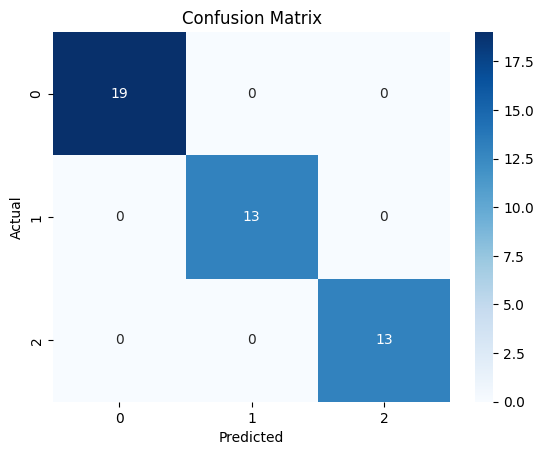

In [22]:
# 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

Mean Absolute Error (MAE): 0.8664984635504496


In [24]:
# 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.9922104644326867


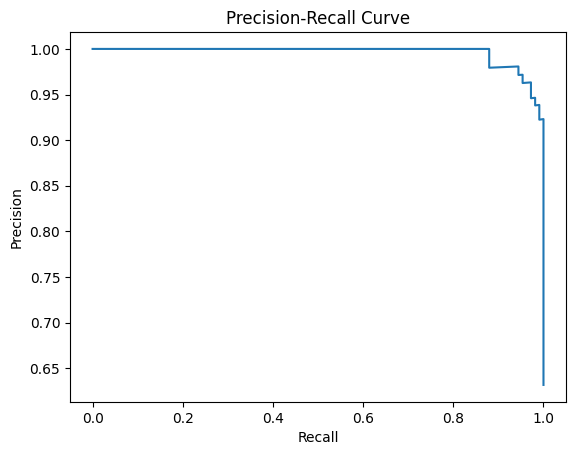

In [25]:
# 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42
)

model = SVC(probability=True)
model.fit(X_train, y_train)

y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()